In [1]:
# --- Работа с данными и СУБД ---
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text 

# --- Обработка текста и регулярные выражения ---
import re
import string
import nltk
from nltk.stem import WordNetLemmatizer

# --- Машинное обучение: Инструменты и метрики ---
from sklearn.pipeline import Pipeline

# --- Машинное обучение: Векторизация и кластеризация ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD # PCA
from sklearn.cluster import KMeans


# --- Визуализация данных ---
import seaborn as sns

Даны три таблицы:

**user_data** - данные о пользователях\
**post_data** - данные о постах\
**feed_data** - данные о действиях пользователей

In [2]:
# функция для выгрузки данных 
engine = create_engine(
    "postgresql://robot-startml-ro:pheiph0hahj1Vaif@"
    "postgres.lab.karpov.courses:6432/startml"
)

def data_upload(q):
    with engine.connect() as conn:
        data = pd.read_sql(text(q), con=conn)
        return data

In [3]:
# Выгрузим и посмотрим на базу пользователей
query = 'SELECT * FROM public.user_data'

user_data = data_upload(query)

In [4]:
print(f'Размер таблицы пользователей: {user_data.shape}')
user_data.head()

Размер таблицы пользователей: (163205, 8)


,user_id,gender,age,country,city,exp_group,os,source
0,200,1,34,Russia,Degtyarsk,3,Android,ads
1,201,0,37,Russia,Abakan,0,Android,ads
2,202,1,17,Russia,Smolensk,4,Android,ads
3,203,0,18,Russia,Moscow,1,iOS,ads
4,204,0,36,Russia,Anzhero-Sudzhensk,3,Android,ads


In [5]:
for col in user_data.columns:
    print(f'{col:<10} {user_data[col].nunique():<7} {user_data[col].dtypes}')

user_id    163205  int64
gender     2       int64
age        76      int64
country    11      object
city       3915    object
exp_group  5       int64
os         2       object
source     2       object


Описание базы данных пользователей:

**user_id** - уникальный идентификатор пользователя\
**gender** - пол пользователя\
**age** - возраст пользователя\
**country** - страна пользователя\
**city** - город пользователя\
**exp_group** - экспериментальная группа: некоторая зашифрованная категория\
**os** - операционная система устройства, с которого происходит пользование соц.сетью\
**source** - пришел ли пользователь в приложение с органического трафика или с рекламы

Категориальные колонки - ['exp_group', 'os', 'source', 'country', 'city']

In [6]:
# Проверяем на пропуски
user_data.isna().sum()

user_id      0
gender       0
age          0
country      0
city         0
exp_group    0
os           0
source       0
dtype: int64

<Axes: >

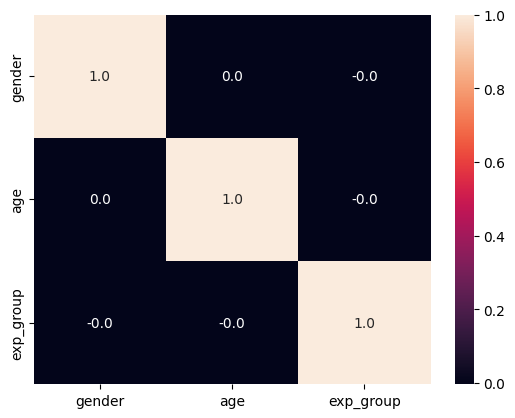

In [7]:
numeric_data = user_data.select_dtypes(exclude='object').drop(columns=['user_id'])

sns.heatmap(numeric_data.corr(method='pearson'), annot=True, fmt=".1f")

In [8]:
# Выгрузим и посмотрим на базу постов
query = 'SELECT * FROM public.post_text_df'

post_data = data_upload(query)

In [9]:
print(f'Размер таблицы постов: {post_data.shape}')
post_data.head()

Размер таблицы постов: (7023, 3)


,post_id,text,topic
0,1,UK economy facing major risks\n\nThe UK manufa...,business
1,2,Aids and climate top Davos agenda\n\nClimate c...,business
2,3,Asian quake hits European shares\n\nShares in ...,business
3,4,India power shares jump on debut\n\nShares in ...,business
4,5,Lacroix label bought by US firm\n\nLuxury good...,business


In [10]:
for col in post_data.columns:
    print(f'{col:<10} {post_data[col].nunique():<7} {post_data[col].dtypes}')

post_id    7023    int64
text       6924    object
topic      7       object


Описание базы данных постов:

**post_id** - уникальный идентификатор поста\
**text** - текстовое содержание поста\
**topic** - основная тематика
	
Категориальные колонки - ['topic']

In [11]:
# проверяем на пропуски
post_data.isna().sum()

post_id    0
text       0
topic      0
dtype: int64

In [12]:
# Предобработка текста
nltk.download("wordnet")
wnl = WordNetLemmatizer()

def preprocessing(line, token=wnl):
    if not isinstance(line, str): return ""
    line = line.lower()
    
    # Удаление скрытых и спец-символов
    line = re.sub(r'[\xa0\u200b\u202f\u2019\u2013\u2014]', ' ', line)
    # Удаление пунктуации
    line = re.sub(r"[{}]".format(string.punctuation), " ", line) 
    # Удаление переносов и лишних пробелов
    line = line.replace('\n\n', ' ').replace('\n', ' ')
    line = re.sub(r'\s+', ' ', line).strip()
    
    return ' '.join([token.lemmatize(x) for x in line.split(' ') if x])


post_data['cleaned_text'] = post_data['text'].apply(preprocessing)

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [13]:
# TF-IDF + PCA
content_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('svd', TruncatedSVD(n_components=50, random_state=42))
])

pca_features = content_pipe.fit_transform(post_data['cleaned_text'])

In [14]:
#Кластеризация и сохранение признаков
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Расчет расстояний
distances = kmeans.fit_transform(pca_features)

# Добавление признаков
post_data['TextCluster'] = pd.Series(kmeans.labels_).astype('category')

dist_cols = [f'DistanceToCluster_{i}' for i in range(n_clusters)]
dist_df = pd.DataFrame(distances, columns=dist_cols, index=post_data.index)

post_data = pd.concat([post_data, dist_df], axis=1)

In [15]:
post_data

,post_id,text,topic,cleaned_text,TextCluster,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,...,DistanceToCluster_10,DistanceToCluster_11,DistanceToCluster_12,DistanceToCluster_13,DistanceToCluster_14,DistanceToCluster_15,DistanceToCluster_16,DistanceToCluster_17,DistanceToCluster_18,DistanceToCluster_19
0,1,UK economy facing major risks\n\nThe UK manufa...,business,uk economy facing major risk the uk manufactur...,14,0.636230,0.633615,0.581913,0.592647,0.606914,...,0.727031,0.630480,0.648437,0.489568,0.196231,0.595334,0.553806,0.541089,0.640970,0.717553
1,2,Aids and climate top Davos agenda\n\nClimate c...,business,aid and climate top davos agenda climate chang...,5,0.529238,0.403139,0.459123,0.482402,0.491887,...,0.632958,0.525736,0.563013,0.357672,0.437936,0.478380,0.438908,0.417150,0.505801,0.626773
2,3,Asian quake hits European shares\n\nShares in ...,business,asian quake hit european share share in europe...,13,0.540514,0.591168,0.484770,0.484785,0.509249,...,0.657663,0.545015,0.591492,0.271421,0.361194,0.488691,0.471563,0.458622,0.539903,0.642366
3,4,India power shares jump on debut\n\nShares in ...,business,india power share jump on debut share in india...,13,0.609520,0.632115,0.551190,0.562594,0.580202,...,0.704773,0.604009,0.648761,0.383920,0.536126,0.566276,0.547427,0.521621,0.607521,0.697400
4,5,Lacroix label bought by US firm\n\nLuxury good...,business,lacroix label bought by u firm luxury good gro...,13,0.402936,0.442078,0.317361,0.347114,0.359841,...,0.540266,0.403025,0.462114,0.155175,0.400684,0.330200,0.302312,0.286064,0.416164,0.527804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7018,7315,"OK, I would not normally watch a Farrelly brot...",movie,ok i would not normally watch a farrelly broth...,0,0.314807,0.618771,0.520725,0.346137,0.473655,...,0.681303,0.574269,0.613678,0.527949,0.601583,0.341942,0.497886,0.529117,0.577421,0.669040
7019,7316,I give this movie 2 stars purely because of it...,movie,i give this movie 2 star purely because of it ...,0,0.142311,0.532734,0.393454,0.264106,0.317647,...,0.593765,0.463734,0.492319,0.402215,0.495314,0.191403,0.404293,0.399828,0.486915,0.572575
7020,7317,I cant believe this film was allowed to be mad...,movie,i cant believe this film wa allowed to be made...,4,0.455307,0.593846,0.463998,0.372120,0.226424,...,0.643261,0.527673,0.528893,0.478593,0.572719,0.361666,0.462049,0.486054,0.546393,0.631184
7021,7318,The version I saw of this film was the Blockbu...,movie,the version i saw of this film wa the blockbus...,3,0.410913,0.536865,0.432272,0.242020,0.285704,...,0.618347,0.497982,0.453114,0.422566,0.519521,0.345994,0.410609,0.438365,0.493924,0.603006


Посмотрим на базу просмотров постов.

> База feed огромная и долго грузится, поэтому я ее заранее загрузила и сохранила у себя.

In [16]:
feed = pd.read_csv('/kaggle/input/feed-data/feed.csv', index_col=0)

In [17]:
print(f'Размер таблицы действий: {feed.shape}')
feed.head()

Размер таблицы действий: (16320500, 5)


,timestamp,user_id,post_id,action,target
0,2021-12-29 15:24:59,200,1773,view,0
1,2021-12-29 15:24:57,200,2213,like,0
2,2021-12-29 15:24:31,200,2213,view,1
3,2021-12-29 15:23:54,200,1122,view,0
4,2021-12-29 15:23:29,200,1362,view,0


In [18]:
feed['timestamp'] = pd.to_datetime(feed['timestamp'])
feed[feed['action']=='view'].target.value_counts()

target
0    12607081
1     1847330
Name: count, dtype: int64

Перед рассчетом динамических признаков отсортируем по времени базу feed и разделим на **train** / **test**, чтобы избежать утечки данных. Оставим только строчки, где 'action' == 'view', т.к. 'like' дублирует информацию

In [19]:
feed_data = feed[feed['action'] == 'view'].sort_values('timestamp')
feed_data = feed_data.drop('action', axis=1)

# Делим на трейн/тест
train_feed = feed_data.iloc[:-1500000].copy()
test_feed = feed_data.iloc[-1500000:].copy()

Убедимся, что в тестовую часть попало достаточно данных

In [20]:
duration = test_feed['timestamp'].max() - test_feed['timestamp'].min()
print(f"Длительность теста: {duration}")

print(f"Начало: {test_feed['timestamp'].min()}")
print(f"Конец: {test_feed['timestamp'].max()}")

Длительность теста: 1 days 16:19:16
Начало: 2021-12-28 07:31:50
Конец: 2021-12-29 23:51:06


In [21]:
# Посмотрим активность пользователей (мин. кол-во просмотренных постов)
train_feed['user_id'].value_counts(ascending=True)

user_id
100909      6
26975       7
161304      7
33783       7
57941       7
         ... 
6406      100
26392     100
159694    100
31530     100
93531     100
Name: count, Length: 163205, dtype: int64

In [22]:
# Глобальный средний CTR (базовая вероятность лайка в системе)
global_avg_ctr = train_feed['target'].mean()
alpha = 20

# 1. Популярность постов (CTR)
post_stats = train_feed.groupby('post_id').agg(
    post_likes=('target', 'sum'),
    post_views=('target', 'count')
).reset_index()

post_stats['post_ctr'] = post_stats['post_likes'] / post_stats['post_views']

# 2. Активность пользователей СО СГЛАЖИВАНИЕМ
user_stats = train_feed.groupby('user_id').agg(
    user_total_likes=('target', 'sum'),
    user_total_views=('target', 'count')
).reset_index()

# Применяем формулу: (лайки юзера + альфа * среднее) / (просмотры юзера + альфа)
user_stats['user_avg_ctr'] = (
    (user_stats['user_total_likes'] + alpha * global_avg_ctr) / 
    (user_stats['user_total_views'] + alpha)
)

print(f"Глобальный CTR для сглаживания: {global_avg_ctr:.4f}")

Глобальный CTR для сглаживания: 0.1267


In [23]:
# Сливаем новые признаки с табличками и сохраняем
user_data = user_data.merge(user_stats[['user_id', 'user_avg_ctr']], on='user_id', how='left')
user_data['user_avg_ctr'] = user_data['user_avg_ctr'].fillna(user_data['user_avg_ctr'].mean())

# у постов дропаем text(при обучении он не нужен)
post_data = post_data.drop(['text', 'cleaned_text'], axis=1)
post_data = post_data.merge(post_stats[['post_id', 'post_ctr']], on='post_id', how='left')
post_data['post_ctr'] = post_data['post_ctr'].fillna(post_data['post_ctr'].mean())

In [24]:
user_data.to_sql('ajgerim-dubanaeva-mke5439_user_data', con=engine, if_exists='replace')

205

In [25]:
post_data.to_sql('ajgerim-dubanaeva-mke5439_post_data', con=engine, if_exists='replace')

23

In [26]:
# Сохраним id train/test в feed
test_feed['set_type'] = 'test'
train_feed['set_type'] = 'train'

feed_split = pd.concat([train_feed, test_feed], axis=0).reset_index(drop=True)

In [27]:
feed_split.dtypes

timestamp    datetime64[ns]
user_id               int64
post_id               int64
target                int64
set_type             object
dtype: object

In [28]:
# Преобразуем типы
feed_split = feed_split.astype({
    'user_id': 'int32',
    'post_id': 'int32',
    'target': 'int32',
    'set_type': 'category',
})

In [29]:
# Сохраняю в parquet, т.к. грузить на сервер и с сервера долго
feed_split.to_parquet('feed_eda.parquet', engine='pyarrow', compression='snappy')